# Data Preprocessing for IoT Network Intrusion Detection

This notebook demonstrates the preprocessing steps for the BoT-IoT dataset, including:
- Data loading and validation
- Feature selection (10 best features)
- Missing value handling
- Label encoding
- Feature scaling
- Train-validation-test split
- Sequence generation for LSTM models
- Data quality assessment

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Load Configuration](#2-load-configuration)
3. [Data Loading](#3-data-loading)
4. [Feature Selection](#4-feature-selection)
5. [Label Encoding](#5-label-encoding)
6. [Data Splitting](#6-data-splitting)
7. [Feature Scaling](#7-feature-scaling)
8. [Sequence Generation](#8-sequence-generation)
9. [Data Quality Assessment](#9-data-quality-assessment)
10. [Save Processed Data](#10-save-processed-data)


## 1. Setup and Imports


In [6]:
# Import necessary libraries
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import warnings

# Add src directory to path
sys.path.append(str(Path().resolve().parent / "src"))

from data_loader import IoTDataLoader
from preprocessor import IoTPreprocessor

# Set style and ignore warnings
plt.style.use('default')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")
print("Preprocessing pipeline ready!")


Libraries imported successfully!
Preprocessing pipeline ready!


## 2. Load Configuration


In [7]:
# Load configuration
config_path = "../config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded successfully!")
print("\nKey preprocessing parameters:")
print(f"• Sequence length: {config['sequences']['sequence_length']}")
print(f"• Test size: {config['preprocessing']['test_size']}")
print(f"• Validation size: {config['preprocessing']['val_size']}")
print(f"• Scaling method: {config['preprocessing']['scaling_method']}")
print(f"• Random state: {config['preprocessing']['random_state']}")
print(f"• Handle imbalance: {config['preprocessing']['handle_imbalance']}")

# Display full config
print("\nFull configuration:")
print(yaml.dump(config, default_flow_style=False))


Configuration loaded successfully!

Key preprocessing parameters:
• Sequence length: 15
• Test size: 0.15
• Validation size: 0.15
• Scaling method: standard
• Random state: 42
• Handle imbalance: False

Full configuration:
callbacks:
  early_stopping:
    monitor: val_loss
    patience: 10
    restore_best_weights: true
  model_checkpoint:
    monitor: val_loss
    save_best_only: true
  reduce_lr:
    factor: 0.5
    min_lr: 1.0e-05
    monitor: val_loss
    patience: 5
cnn_lstm:
  conv_dropout: 0.3
  conv_filters_1: 64
  conv_filters_2: 128
  dense_dropout: 0.3
  dense_units: 32
  kernel_size: 3
  lstm_dropout: 0.3
  lstm_units: 64
  name: CNN-LSTM
  output_activation: softmax
  pool_size: 2
  return_sequences: false
data:
  file_pattern: UNSW_2018_IoT_Botnet_Final_10_Best.csv
  num_classes: 5
  num_features: 10
  processed_path: data/processed/
  raw_path: data/raw/
evaluation:
  confusion_matrix: true
  metrics:
  - accuracy
  - precision
  - recall
  - f1_score
  - auc_roc
  per_c

## 3. Data Loading


In [8]:
# Load the dataset
data_path = "../data/raw"
loader = IoTDataLoader(data_path)

print("Loading BoT-IoT dataset...")
data = loader.load_data()
print("Dataset loaded successfully!")

# Display basic information
print(f"\nDataset Information:")
print(f"• Shape: {data.shape}")
print(f"• Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"• Columns: {list(data.columns)}")

# Check for missing values
missing_values = data.isnull().sum()
print(f"\nMissing values:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")

# Display first few rows
print(f"\nFirst 3 rows:")
print(data.head(3))


INFO:data_loader:Loading data from ../data/raw with pattern UNSW_2018_IoT_Botnet_Final_10_Best.csv
INFO:data_loader:Found 1 CSV files: ['../data/raw\\UNSW_2018_IoT_Botnet_Final_10_Best.csv']
INFO:data_loader:Loading ../data/raw\UNSW_2018_IoT_Botnet_Final_10_Best.csv


Loading BoT-IoT dataset...


INFO:data_loader:Loaded 3668522 rows from UNSW_2018_IoT_Botnet_Final_10_Best.csv
INFO:data_loader:Combined dataset shape: (3668522, 20)


Dataset loaded successfully!

Dataset Information:
• Shape: (3668522, 20)
• Memory usage: 1776.51 MB
• Columns: ['Unnamed: 0', 'pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory']

Missing values:
No missing values found

First 3 rows:
   Unnamed: 0  pkSeqID proto            saddr  sport            daddr dport  \
0           0        1   tcp  192.168.100.147  49960    192.168.100.7    80   
1           1        2   arp    192.168.100.7     -1  192.168.100.147    -1   
2           2        3   tcp  192.168.100.147  49962    192.168.100.7    80   

   seq    stddev  N_IN_Conn_P_SrcIP       min  state_number      mean  \
0    9  0.068909                 75  0.000000             1  0.068909   
1   10  0.000000                  2  0.000131             2  0.000131   
2   11  0.064494                 75  0.000000             1  0.064494   


## 4. Initialize Preprocessor


In [9]:
# Initialize preprocessor with config dictionary
preprocessor = IoTPreprocessor(config)

print("Preprocessor initialized successfully!")
print(f"\nPreprocessor configuration:")
cfg = preprocessor.config
print(f"• Test size: {cfg['preprocessing']['test_size']}")
print(f"• Validation size: {cfg['preprocessing']['val_size']}")
print(f"• Random state: {cfg['preprocessing']['random_state']}")
print(f"• Sequence length: {cfg['sequences']['sequence_length']}")
print(f"• Stride: {cfg['sequences']['stride']}")
print(f"• Number of features: {cfg['data']['num_features']}")
print(f"• Number of classes: {cfg['data']['num_classes']}")
print(f"• Scaling method: {cfg['preprocessing']['scaling_method']}")
print(f"• Handle imbalance: {cfg['preprocessing'].get('handle_imbalance', False)}")


Preprocessor initialized successfully!

Preprocessor configuration:
• Test size: 0.15
• Validation size: 0.15
• Random state: 42
• Sequence length: 15
• Stride: 1
• Number of features: 10
• Number of classes: 5
• Scaling method: standard
• Handle imbalance: False


## 5. Run Complete Preprocessing Pipeline


In [11]:
# Run the complete preprocessing pipeline
print("Running complete preprocessing pipeline...")
print("=" * 50)

# Process the data
metadata = preprocessor.process_full_pipeline(data, "../data/processed")

print("\nPreprocessing completed successfully!")
print("\nProcessing Results:")
print("=" * 30)

for key, value in metadata.items():
    if isinstance(value, (int, float)):
        if 'time' in key.lower():
            print(f"• {key}: {value:.2f} seconds")
        elif 'size' in key.lower() or 'samples' in key.lower():
            print(f"• {key}: {value:,}")
        else:
            print(f"• {key}: {value}")
    else:
        print(f"• {key}: {value}")

# Display class distribution after preprocessing
print(f"\nClass distribution in training set:")
unique_classes, counts = np.unique(metadata['y_train'], return_counts=True)
for class_id, count in zip(unique_classes, counts):
    # Map encoded class id back to class name if available
    cls_name = metadata.get('class_names', None)
    class_name = cls_name[class_id] if isinstance(cls_name, (list, tuple)) and class_id < len(cls_name) else str(class_id)
    percentage = (count / len(metadata['y_train'])) * 100
    print(f"  {class_name:15s}: {count:8,} ({percentage:5.1f}%)")


INFO:preprocessor:Starting complete preprocessing pipeline
INFO:preprocessor:Preparing data: separating features and labels
INFO:preprocessor:Selected 10 best features: ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']


Running complete preprocessing pipeline...


INFO:preprocessor:Features shape: (3668522, 10)
INFO:preprocessor:Labels shape: (3668522,)
INFO:preprocessor:Feature columns: ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']
INFO:preprocessor:Handling missing values
INFO:preprocessor:No missing values found.
INFO:preprocessor:Encoding labels
INFO:preprocessor:Class names: ['DDoS' 'DoS' 'Normal' 'Reconnaissance' 'Theft']
INFO:preprocessor:Class mapping: {'DDoS': 0, 'DoS': 1, 'Normal': 2, 'Reconnaissance': 3, 'Theft': 4}
INFO:preprocessor:Splitting data into train/validation/test sets
INFO:preprocessor:Train set: 2,567,964 samples
INFO:preprocessor:Validation set: 550,279 samples
INFO:preprocessor:Test set: 550,279 samples
INFO:preprocessor:Scaling features using StandardScaler
INFO:preprocessor:Feature scaling completed
INFO:preprocessor:Creating sequences for LSTM input
INFO:preprocessor:Created sequences: (2567950, 15, 10)
INFO:preprocessor:Sequence shape: (batch_size


Preprocessing completed successfully!

Processing Results:
• train_samples: 2,567,950
• val_samples: 550,265
• test_samples: 550,265
• sequence_length: 15
• stride: 1
• num_features: 10
• num_classes: 5
• class_names: ['DDoS', 'DoS', 'Normal', 'Reconnaissance', 'Theft']
• class_weights: {0: 0.3808235023690708, 1: 0.4445993031358885, 2: 1542.3123123123123, 3: 8.055429207773264, 4: 9338.0}
• class_weights_computed: True
• scaling_method: standard
• feature_names: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']
• X_train: [[ 0.39208319 -1.07908446 -0.8819039  ... -0.0070515  -0.00369792
  -1.53617531]
 [ 1.28485338 -0.44484907  0.71604284 ... -0.00765756 -0.00333561
   0.47600369]
 [ 0.20411143 -0.92779343  0.71604284 ... -0.00660764 -0.00368214
  -1.46107949]
 ...
 [-0.77473498  0.13558718  0.71604284 ... -0.00765756 -0.00324011
   0.61629781]
 [ 1.52215668  0.92625326  0.71604284 ... -0.00765756 -0.00346

## 6. Visualize Preprocessing Results


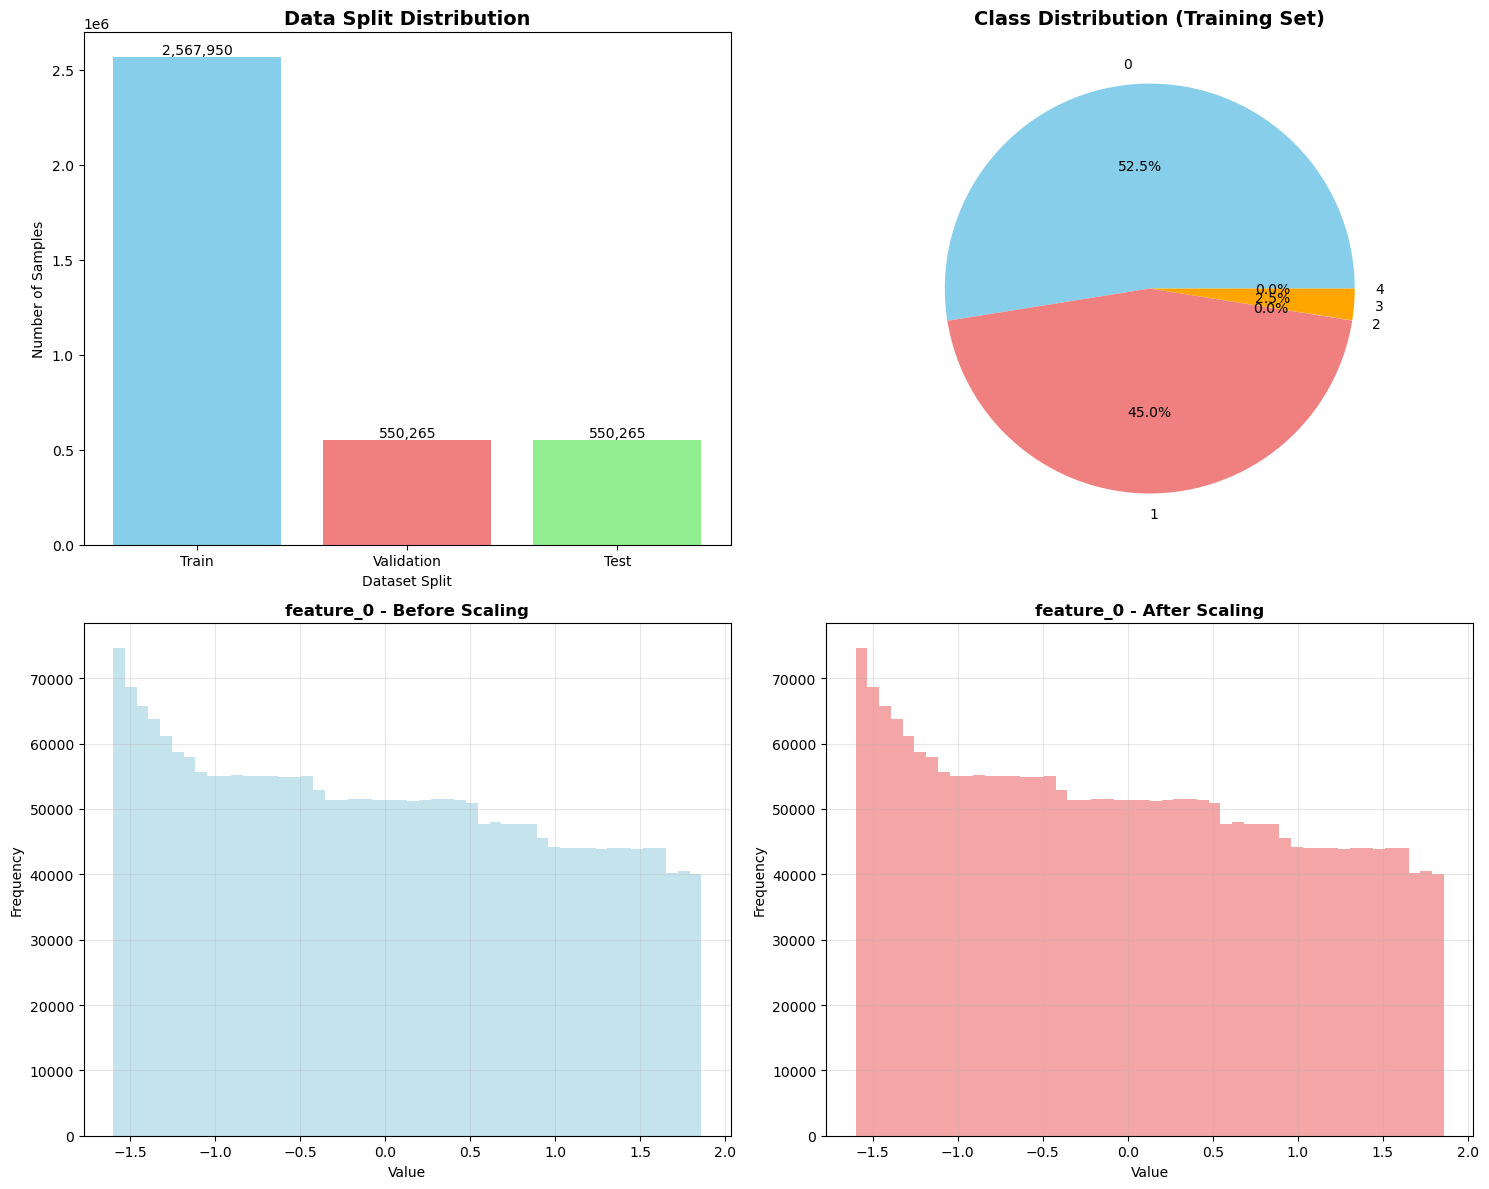


Sequence Generation Results:
• Sequence length: 15
• Stride: 1
• Final training sequences: (2567950, 15, 10)
• Final validation sequences: (550265, 15, 10)
• Final test sequences: (550265, 15, 10)
• Number of features per timestep: 10
• Number of classes: 5


In [12]:
# Create visualizations of preprocessing results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Data split distribution
ax1 = axes[0, 0]
split_labels = ['Train', 'Validation', 'Test']
split_sizes = [metadata['train_samples'], metadata['val_samples'], metadata['test_samples']]
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax1.bar(split_labels, split_sizes, color=colors)
ax1.set_title('Data Split Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Samples')
ax1.set_xlabel('Dataset Split')

# Add value labels on bars
for bar, size in zip(bars, split_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(size):,}', ha='center', va='bottom', fontsize=10)

# 2. Class distribution in training set
ax2 = axes[0, 1]
unique_classes, counts = np.unique(metadata['y_train'], return_counts=True)
wedges, texts, autotexts = ax2.pie(counts, labels=unique_classes, autopct='%1.1f%%', 
                                   colors=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple'])
ax2.set_title('Class Distribution (Training Set)', fontsize=14, fontweight='bold')

# 3. Feature scaling visualization (before vs after)
ax3 = axes[1, 0]
# Show scaling effect for first feature
feature_name = list(metadata['feature_names'])[0]
original_values = metadata['X_train'][:, 0]
scaled_values = metadata['X_train_scaled'][:, 0]

ax3.hist(original_values, bins=50, alpha=0.7, label='Original', color='lightblue')
ax3.set_title(f'{feature_name} - Before Scaling', fontsize=12, fontweight='bold')
ax3.set_xlabel('Value')
ax3.set_ylabel('Frequency')
ax3.grid(True, alpha=0.3)

# 4. Scaled feature distribution
ax4 = axes[1, 1]
ax4.hist(scaled_values, bins=50, alpha=0.7, label='Scaled', color='lightcoral')
ax4.set_title(f'{feature_name} - After Scaling', fontsize=12, fontweight='bold')
ax4.set_xlabel('Value')
ax4.set_ylabel('Frequency')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display sequence information
print(f"\nSequence Generation Results:")
print(f"• Sequence length: {metadata['sequence_length']}")
print(f"• Stride: {metadata['stride']}")
print(f"• Final training sequences: {metadata['X_train_seq'].shape}")
print(f"• Final validation sequences: {metadata['X_val_seq'].shape}")
print(f"• Final test sequences: {metadata['X_test_seq'].shape}")
print(f"• Number of features per timestep: {metadata['X_train_seq'].shape[2]}")
print(f"• Number of classes: {metadata['num_classes']}")


## 7. Summary and Next Steps


In [13]:
# Generate final summary
print("PREPROCESSING SUMMARY:")
print("=" * 40)

print(f"\n1. Data Processing Results:")
print(f"   • Original dataset size: {data.shape}")
print(f"   • Features selected: {len(metadata['feature_names'])}")
print(f"   • Training samples: {metadata['train_samples']:,}")
print(f"   • Validation samples: {metadata['val_samples']:,}")
print(f"   • Test samples: {metadata['test_samples']:,}")

print(f"\n2. Sequence Generation:")
print(f"   • Sequence length: {metadata['sequence_length']}")
print(f"   • Final training sequences: {metadata['X_train_seq'].shape}")
print(f"   • Features per timestep: {metadata['X_train_seq'].shape[2]}")
print(f"   • Number of classes: {metadata['num_classes']}")

print(f"\n3. Data Quality:")
print(f"   • Missing values handled: Yes")
print(f"   • Feature scaling applied: {metadata['scaling_method']}")
print(f"   • Label encoding completed: Yes")
print(f"   • Class weights computed: {metadata.get('class_weights_computed', False)}")

print(f"\n4. Files Generated:")
print(f"   • Processed data saved to: ../data/processed/")
print(f"   • Scaler saved: ../data/processed/scaler.pkl")
print(f"   • Label encoder saved: ../data/processed/label_encoder.pkl")
print(f"   • Metadata saved: ../data/processed/metadata.pkl")

print(f"\n5. Ready for Model Training:")
print(f"   • LSTM-CNN model: Ready")
print(f"   • CNN-LSTM model: Ready")
print(f"   • Training data: {metadata['X_train_seq'].shape}")
print(f"   • Validation data: {metadata['X_val_seq'].shape}")
print(f"   • Test data: {metadata['X_test_seq'].shape}")

print(f"\nPreprocessing completed successfully!")
print(f"Next step: Run model training notebooks or scripts.")


PREPROCESSING SUMMARY:

1. Data Processing Results:
   • Original dataset size: (3668522, 20)
   • Features selected: 10
   • Training samples: 2,567,950
   • Validation samples: 550,265
   • Test samples: 550,265

2. Sequence Generation:
   • Sequence length: 15
   • Final training sequences: (2567950, 15, 10)
   • Features per timestep: 10
   • Number of classes: 5

3. Data Quality:
   • Missing values handled: Yes
   • Feature scaling applied: standard
   • Label encoding completed: Yes
   • Class weights computed: True

4. Files Generated:
   • Processed data saved to: ../data/processed/
   • Scaler saved: ../data/processed/scaler.pkl
   • Label encoder saved: ../data/processed/label_encoder.pkl
   • Metadata saved: ../data/processed/metadata.pkl

5. Ready for Model Training:
   • LSTM-CNN model: Ready
   • CNN-LSTM model: Ready
   • Training data: (2567950, 15, 10)
   • Validation data: (550265, 15, 10)
   • Test data: (550265, 15, 10)

Preprocessing completed successfully!
Next s